# Exploration — Base HDF5 MEB

Accès aux représentations internes de TextureSAM (16 blocs trunk + 4 FPN) pour les patches annotés MEB.

In [27]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import h5py
import numpy as np
import json
from pathlib import Path

ROOT     = Path('..').resolve()
DB_PATH  = ROOT / 'data' / 'feature_database' / 'database_meb.h5'
CFG_PATH = ROOT / 'PatchTagger_Output' / 'config' / 'config.json'

with open(CFG_PATH) as f:
    cfg = json.load(f)
CATEGORIES = {int(k): v['name'] for k, v in cfg['available_categories'].items()}

print(f'DB   : {DB_PATH}')
print(f'Cats : {len(CATEGORIES)} catégories')
for k, v in CATEGORIES.items():
    print(f'  {k:2d}  {v}')

DB   : /home/aidouni/meb_texture_seg/data/feature_database/database_meb.h5
Cats : 13 catégories
   1  Totalement homogène
   2  Plutôt homogène
   3  Faisceaux
   4  Filaments
   5  Stratifié rectiligne
   6  Stratifié sinueux
   7  Granuleux
   8  Sableux
   9  Trou
  10  Bactéries
  11  (portion de) Cellule
  12  Calcification
  13  Nd


## Cell 1 — Vérification structure

In [28]:
with h5py.File(DB_PATH, 'r') as h5:

    N = h5['metadata/category_ids'].shape[0]

    # 1. Clés features avec shapes
    print('=== FEATURES ===')
    for key in sorted(h5['features'].keys()):
        shape = h5['features'][key].shape
        ok    = shape[0] == N
        print(f'  {key:15s} : {shape}  {"✅" if ok else "❌"}')

    # 2. Vecteurs nuls
    print('\n=== VECTEURS NULS ===')
    for key in ['block_0', 'block_7', 'block_13', 'stage_3_fpn']:
        feats  = h5['features'][key][:]
        n_nuls = (np.linalg.norm(feats, axis=1) < 1e-6).sum()
        print(f'  {key:15s} : {n_nuls} nuls  {"✅" if n_nuls == 0 else "❌"}')

    # 3. L2-normalisation
    print('\n=== L2-NORMALISATION ===')
    for key in ['block_0', 'block_13', 'stage_3_fpn']:
        feats = h5['features'][key][:]
        norms = np.linalg.norm(feats, axis=1)
        ok    = abs(norms.mean() - 1.0) < 0.01
        print(f'  {key:15s} : mean={norms.mean():.4f}  '
              f'std={norms.std():.4f}  {"✅" if ok else "⚠️"}')

    # 4. Distribution catégories
    print('\n=== DISTRIBUTION CATÉGORIES ===')
    cats = h5['metadata/category_ids'][:]
    print(f'{"Cat":>4}  {"Nom":<30}  {"N patches":>10}')
    print('─' * 48)
    for cat_id in sorted(np.unique(cats)):
        n    = (cats == cat_id).sum()
        name = CATEGORIES.get(int(cat_id), '?')
        print(f'  {cat_id:>2}  {name:<30}  {n:>10}')
    print(f'{"TOTAL":<35}  {len(cats):>10}')

    # 5. Distribution images
    print('\n=== DISTRIBUTION IMAGES ===')
    imgs = h5['metadata/image_names'][:]
    unique_imgs, counts = np.unique(imgs, return_counts=True)
    idx_sort = np.argsort(-counts)
    print(f'{"Image":<45}  {"N patches":>10}')
    print('─' * 57)
    for i in idx_sort[:10]:
        print(f'  {unique_imgs[i].decode()[-43:]:<43}  {counts[i]:>10}')
    print(f'\n  Total images     : {len(unique_imgs)}')
    print(f'  Moy patches/image: {counts.mean():.1f}')

    # 6. Positions valides
    print('\n=== POSITIONS ===')
    pos  = h5['metadata/positions'][:]
    ok_x = (pos[:, 2] > pos[:, 0]).all()
    ok_y = (pos[:, 3] > pos[:, 1]).all()
    print(f'  x_min : [{pos[:, 0].min():.0f} – {pos[:, 0].max():.0f}]')
    print(f'  y_min : [{pos[:, 1].min():.0f} – {pos[:, 1].max():.0f}]')
    print(f'  x_max : [{pos[:, 2].min():.0f} – {pos[:, 2].max():.0f}]')
    print(f'  y_max : [{pos[:, 3].min():.0f} – {pos[:, 3].max():.0f}]')
    print(f'  x_max > x_min : {"✅" if ok_x else "❌"}')
    print(f'  y_max > y_min : {"✅" if ok_y else "❌"}')

=== FEATURES ===
  block_0         : (3583, 96)  ✅
  block_1         : (3583, 192)  ✅
  block_10        : (3583, 384)  ✅
  block_11        : (3583, 384)  ✅
  block_12        : (3583, 384)  ✅
  block_13        : (3583, 384)  ✅
  block_14        : (3583, 768)  ✅
  block_15        : (3583, 768)  ✅
  block_2         : (3583, 192)  ✅
  block_3         : (3583, 384)  ✅
  block_4         : (3583, 384)  ✅
  block_5         : (3583, 384)  ✅
  block_6         : (3583, 384)  ✅
  block_7         : (3583, 384)  ✅
  block_8         : (3583, 384)  ✅
  block_9         : (3583, 384)  ✅
  stage_1_fpn     : (3583, 256)  ✅
  stage_2_fpn     : (3583, 256)  ✅
  stage_3_fpn     : (3583, 256)  ✅
  stage_4_fpn     : (3583, 256)  ✅

=== VECTEURS NULS ===
  block_0         : 0 nuls  ✅
  block_7         : 0 nuls  ✅
  block_13        : 0 nuls  ✅
  stage_3_fpn     : 0 nuls  ✅

=== L2-NORMALISATION ===
  block_0         : mean=1.0000  std=0.0000  ✅
  block_13        : mean=1.0000  std=0.0000  ✅
  stage_3_fpn     : m

## Cell 2 — Fonctions d'accès

In [29]:
# ── Metadata chargée une fois en mémoire globale ──────────────────────────────
with h5py.File(DB_PATH, 'r') as h5:
    IMAGE_NAMES    = h5['metadata/image_names'][:]
    POSITIONS      = h5['metadata/positions'][:]
    CATEGORY_IDS   = h5['metadata/category_ids'][:]
    CATEGORY_NAMES = h5['metadata/category_names'][:]


def get_patches_image(image_name: str) -> dict:
    """Tous les patches d'une image donnée."""
    mask = IMAGE_NAMES == image_name.encode()
    idx  = np.where(mask)[0]
    return {
        'idx'       : idx,
        'positions' : POSITIONS[idx],
        'categories': CATEGORY_IDS[idx],
        'names'     : [n.decode() for n in CATEGORY_NAMES[idx]],
        'n'         : len(idx),
    }


def get_features(indices, key: str = 'stage_3_fpn') -> np.ndarray:
    """Features (N, dim) d'un ensemble de patches."""
    with h5py.File(DB_PATH, 'r') as h5:
        return h5['features'][key][indices]


def get_patches_category(cat_id: int, key: str = 'stage_3_fpn') -> dict:
    """Tous les patches d'une catégorie."""
    mask = CATEGORY_IDS == cat_id
    idx  = np.where(mask)[0]
    with h5py.File(DB_PATH, 'r') as h5:
        feats = h5['features'][key][:][mask]
    return {'idx': idx, 'features': feats, 'n': len(idx)}


def get_patch(patch_idx: int) -> dict:
    """Toutes les infos d'un patch précis (toutes les couches)."""
    result = {
        'image'   : IMAGE_NAMES[patch_idx].decode(),
        'position': POSITIONS[patch_idx],
        'cat_id'  : int(CATEGORY_IDS[patch_idx]),
        'cat_name': CATEGORY_NAMES[patch_idx].decode(),
    }
    with h5py.File(DB_PATH, 'r') as h5:
        result['features'] = {
            key: h5['features'][key][patch_idx]
            for key in h5['features'].keys()
        }
    return result


def nearest_neighbors(patch_idx: int, key: str = 'stage_3_fpn',
                      k: int = 5, cross_image: bool = True) -> dict:
    """k plus proches voisins (similarité cosinus — vecteurs déjà L2-normalisés)."""
    with h5py.File(DB_PATH, 'r') as h5:
        X = h5['features'][key][:]
    q         = X[patch_idx]
    sim       = X @ q
    sim[patch_idx] = -1                          # exclure soi-même
    if cross_image:                              # exclure même image
        mask_same       = IMAGE_NAMES == IMAGE_NAMES[patch_idx]
        sim[mask_same]  = -1
    top_k = np.argsort(sim)[-k:][::-1]
    return {
        'indices'     : top_k,
        'similarities': sim[top_k],
        'categories'  : [CATEGORIES[int(c)] for c in CATEGORY_IDS[top_k]],
        'images'      : [n.decode() for n in IMAGE_NAMES[top_k]],
    }


# ── Tests rapides ─────────────────────────────────────────────────────────────
TEST_IMAGE = '060525-JPB-MEB-EIHNValves-Ech1-ZigZag20002.tif'
TEST_PATCH = 25

print('=== TEST get_patches_image ===')
res = get_patches_image(TEST_IMAGE)
print(f'  {res["n"]} patches')
for i in range(min(res['n'], 8)):
    print(f'  [{res["idx"][i]}] {res["names"][i]:<28} pos={res["positions"][i]}')

print('\n=== TEST get_patches_category (Granuleux = 7) ===')
res = get_patches_category(7)
print(f'  {res["n"]} patches  shape={res["features"].shape}')

print(f'\n=== TEST get_patch (patch {TEST_PATCH}) ===')
p = get_patch(TEST_PATCH)
print(f'  Image    : {p["image"]}')
print(f'  Position : {p["position"]}')
print(f'  Catégorie: {p["cat_name"]}')
for key, v in sorted(p['features'].items()):
    print(f'  {key:15s} : shape={v.shape}  norm={np.linalg.norm(v):.4f}')

print(f'\n=== TEST nearest_neighbors (patch {TEST_PATCH}, stage_3_fpn) ===')
nn = nearest_neighbors(TEST_PATCH, key='stage_3_fpn', k=5)
print(f'  {"Rang":<5} {"Sim":>6}  {"Catégorie":<28}  Image')
for i in range(5):
    print(f'  {i+1:<5} {nn["similarities"][i]:>6.3f}  '
          f'{nn["categories"][i]:<28}  '
          f'{nn["images"][i][-35:]}')

=== TEST get_patches_image ===
  60 patches
  [0] Nd                           pos=[  0.   0. 128. 128.]
  [1] Totalement homogène          pos=[128.   0. 256. 128.]
  [2] Totalement homogène          pos=[256.   0. 384. 128.]
  [3] Totalement homogène          pos=[384.   0. 512. 128.]
  [4] Plutôt homogène              pos=[512.   0. 640. 128.]
  [5] Plutôt homogène              pos=[640.   0. 768. 128.]
  [6] Nd                           pos=[768.   0. 896. 128.]
  [7] Plutôt homogène              pos=[ 896.    0. 1024.  128.]

=== TEST get_patches_category (Granuleux = 7) ===
  409 patches  shape=(409, 256)

=== TEST get_patch (patch 25) ===
  Image    : 060525-JPB-MEB-EIHNValves-Ech1-ZigZag20002.tif
  Position : [640. 256. 768. 384.]
  Catégorie: Granuleux
  block_0         : shape=(96,)  norm=1.0000
  block_1         : shape=(192,)  norm=1.0000
  block_10        : shape=(384,)  norm=1.0000
  block_11        : shape=(384,)  norm=1.0000
  block_12        : shape=(384,)  norm=1.0000

## Cell 3 — Fisher Criterion par block

In [ ]:
import pickle as _fsh_pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA as _fsh_PCA
from tqdm.auto import tqdm

_fsh_PCA_DIM = 50
_fsh_SEED    = 42
_fsh_MIN_N   = 30

_fsh_EXCLUDE = {2, 8, 10, 11, 12, 13}   # Plutôt hom., Sableux, Bactéries,
                                          # Portion cellule, Calcif., Nd

_fsh_CATS_VALID = sorted([
    int(c) for c in np.unique(CATEGORY_IDS)
    if int(c) not in _fsh_EXCLUDE
    and (CATEGORY_IDS == c).sum() >= _fsh_MIN_N
])

_fsh_KEYS_ORDER = [
    'block_0',
    'block_1',  'block_2',
    'block_3',  'block_4',  'block_5',  'block_6',  'block_7',
    'block_8',  'block_9',  'block_10', 'block_11', 'block_12', 'block_13',
    'block_14', 'block_15',
    'stage_1_fpn', 'stage_2_fpn', 'stage_3_fpn', 'stage_4_fpn',
]

_fsh_STAGE_ZONES = [
    (0,  0,  '#DBEAFE', 'Stage 1'),
    (1,  2,  '#D1FAE5', 'Stage 2'),
    (3,  13, '#FEF3C7', 'Stage 3'),
    (14, 15, '#FEE2E2', 'Stage 4'),
    (16, 19, '#EDE9FE', 'FPN'),
]

print('Catégories utilisées :')
for _fsh_c in _fsh_CATS_VALID:
    _fsh_n = (CATEGORY_IDS == _fsh_c).sum()
    print(f'  Cat {_fsh_c:2d}  {CATEGORIES[_fsh_c]:<30} N={_fsh_n}')
print(f'\nPCA : {_fsh_PCA_DIM}d  |  blocks : {len(_fsh_KEYS_ORDER)}')

# ── Calcul Fisher original + balancé ─────────────────────────────────────────
_fsh_results = {}

with h5py.File(DB_PATH, 'r') as h5:
    for _fsh_key in tqdm(_fsh_KEYS_ORDER, desc='Fisher'):

        _fsh_X_raw = h5['features'][_fsh_key][:]
        _fsh_mask  = np.isin(CATEGORY_IDS, _fsh_CATS_VALID)
        _fsh_X     = _fsh_X_raw[_fsh_mask]
        _fsh_y     = CATEGORY_IDS[_fsh_mask]

        # PCA fit sur les patches des catégories retenues uniquement
        _fsh_n_comp = min(_fsh_PCA_DIM, _fsh_X.shape[1])
        _fsh_pca    = _fsh_PCA(n_components=_fsh_n_comp, random_state=_fsh_SEED)
        _fsh_X50    = _fsh_pca.fit_transform(_fsh_X)          # (N_valid, 50)

        _fsh_D  = _fsh_X50.shape[1]
        _fsh_mu = _fsh_X50.mean(axis=0)                        # centroïde global

        # ── S_B original (pondéré N_c) et S_B balancé (sans N_c) ─────────────
        _fsh_S_B     = np.zeros((_fsh_D, _fsh_D))
        _fsh_S_B_bal = np.zeros((_fsh_D, _fsh_D))

        for _fsh_c in _fsh_CATS_VALID:
            _fsh_mask_c = _fsh_y == _fsh_c
            _fsh_N_c    = _fsh_mask_c.sum()
            _fsh_mu_c   = _fsh_X50[_fsh_mask_c].mean(axis=0)
            _fsh_diff   = (_fsh_mu_c - _fsh_mu).reshape(-1, 1)
            _fsh_S_B     += _fsh_N_c * (_fsh_diff @ _fsh_diff.T)   # original
            _fsh_S_B_bal +=             _fsh_diff @ _fsh_diff.T    # balancé

        # ── S_W original (somme brute) et S_W balancé (normalisé 1/N_c) ──────
        _fsh_S_W     = np.zeros((_fsh_D, _fsh_D))
        _fsh_S_W_bal = np.zeros((_fsh_D, _fsh_D))

        for _fsh_c in _fsh_CATS_VALID:
            _fsh_mask_c  = _fsh_y == _fsh_c
            _fsh_N_c     = _fsh_mask_c.sum()
            _fsh_mu_c    = _fsh_X50[_fsh_mask_c].mean(axis=0)
            _fsh_diff_c  = _fsh_X50[_fsh_mask_c] - _fsh_mu_c
            _fsh_cov_c   = _fsh_diff_c.T @ _fsh_diff_c
            _fsh_S_W     += _fsh_cov_c                              # original
            _fsh_S_W_bal += (1.0 / _fsh_N_c) * _fsh_cov_c          # balancé

        # ── Critères J ────────────────────────────────────────────────────────
        _fsh_tr_SB     = np.trace(_fsh_S_B)
        _fsh_tr_SW     = np.trace(_fsh_S_W)
        _fsh_tr_SB_bal = np.trace(_fsh_S_B_bal)
        _fsh_tr_SW_bal = np.trace(_fsh_S_W_bal)

        _fsh_J     = _fsh_tr_SB     / (_fsh_tr_SW     + 1e-10)
        _fsh_J_bal = _fsh_tr_SB_bal / (_fsh_tr_SW_bal + 1e-10)

        # ── J_per_cat original et balancé ─────────────────────────────────────
        _fsh_J_per_cat     = {}
        _fsh_J_per_cat_bal = {}

        for _fsh_c in _fsh_CATS_VALID:
            _fsh_mask_c  = _fsh_y == _fsh_c
            _fsh_N_c     = _fsh_mask_c.sum()
            _fsh_mu_c    = _fsh_X50[_fsh_mask_c].mean(axis=0)
            _fsh_diff    = (_fsh_mu_c - _fsh_mu).reshape(-1, 1)
            _fsh_tr_diff = float(np.trace(_fsh_diff @ _fsh_diff.T))

            _fsh_J_per_cat[_fsh_c]     = (_fsh_N_c * _fsh_tr_diff) / (_fsh_tr_SW     + 1e-10)
            _fsh_J_per_cat_bal[_fsh_c] =             _fsh_tr_diff   / (_fsh_tr_SW_bal + 1e-10)

        _fsh_results[_fsh_key] = {
            'J'            : float(_fsh_J),
            'J_bal'        : float(_fsh_J_bal),
            'J_per_cat'    : _fsh_J_per_cat,
            'J_per_cat_bal': _fsh_J_per_cat_bal,
            'tr_SB'        : float(_fsh_tr_SB),
            'tr_SW'        : float(_fsh_tr_SW),
            'tr_SB_bal'    : float(_fsh_tr_SB_bal),
            'tr_SW_bal'    : float(_fsh_tr_SW_bal),
        }

# ── Tableau console ───────────────────────────────────────────────────────────
print(f'\n{"Block":<15} │ {"J original":>11} │ {"J balancé":>10} │ {"Δ":>8}')
print('─' * 52)
for _fsh_key in _fsh_KEYS_ORDER:
    _fsh_j    = _fsh_results[_fsh_key]['J']
    _fsh_jbal = _fsh_results[_fsh_key]['J_bal']
    _fsh_delta = _fsh_jbal - _fsh_j
    _fsh_sign  = '+' if _fsh_delta >= 0 else ''
    print(f'{_fsh_key:<15} │ {_fsh_j:>11.4f} │ {_fsh_jbal:>10.4f} │ '
          f'{_fsh_sign}{_fsh_delta:>7.4f}')

_fsh_best_orig = max(_fsh_results, key=lambda k: _fsh_results[k]['J'])
_fsh_best_bal  = max(_fsh_results, key=lambda k: _fsh_results[k]['J_bal'])
print(f'\nMeilleur block (original) : {_fsh_best_orig} '
      f'→ J={_fsh_results[_fsh_best_orig]["J"]:.4f}')
print(f'Meilleur block (balancé)  : {_fsh_best_bal} '
      f'→ J={_fsh_results[_fsh_best_bal]["J_bal"]:.4f}')

# ── Figure 2×2 ───────────────────────────────────────────────────────────────
_fsh_fig, _fsh_axes = plt.subplots(2, 2, figsize=(16, 12))
(_fsh_ax00, _fsh_ax01), (_fsh_ax10, _fsh_ax11) = _fsh_axes

_fsh_x      = np.arange(len(_fsh_KEYS_ORDER))
_fsh_J_orig = [_fsh_results[k]['J']     for k in _fsh_KEYS_ORDER]
_fsh_J_bal  = [_fsh_results[k]['J_bal'] for k in _fsh_KEYS_ORDER]


def _fsh_draw_curve(ax, y_vals, title):
    """Courbe J + zones stage + annotation max."""
    _fsh_ymax = max(y_vals)
    for _xi, _xf, _col, _lbl in _fsh_STAGE_ZONES:
        ax.axvspan(_xi - 0.5, _xf + 0.5, alpha=0.12, color=_col)
        ax.text((_xi + _xf) / 2, _fsh_ymax * 1.02, _lbl,
                ha='center', fontsize=7, color='#374151', fontweight='bold')
    # Courbes par catégorie
    for _c in _fsh_CATS_VALID:
        _key = 'J_per_cat_bal' if 'balancé' in title else 'J_per_cat'
        _yc  = [_fsh_results[k][_key][_c] for k in _fsh_KEYS_ORDER]
        _hex = cfg['available_categories'][str(_c)]['color']
        ax.plot(_fsh_x, _yc, lw=0.9, alpha=0.35, ls='--', color=_hex)
    # Courbe globale
    ax.plot(_fsh_x, y_vals, 'o-', lw=2.5, ms=5, color='#1B2A4A', zorder=5)
    # Annotation max
    _idx = int(np.argmax(y_vals))
    ax.annotate(
        f'★ {_fsh_KEYS_ORDER[_idx]}\nJ={y_vals[_idx]:.3f}',
        xy=(_idx, y_vals[_idx]),
        xytext=(0, 16), textcoords='offset points',
        ha='center', fontsize=8, fontweight='bold', color='#1B2A4A',
        arrowprops=dict(arrowstyle='->', color='#1B2A4A', lw=1.3),
    )
    ax.set_xticks(_fsh_x)
    ax.set_xticklabels(_fsh_KEYS_ORDER, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('J = tr(S_B) / tr(S_W)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, _fsh_ymax * 1.12)
    ax.grid(True, alpha=0.3, axis='y')


def _fsh_draw_heatmap(ax, key_per_cat, title):
    """Heatmap contribution J_per_cat."""
    _mat = np.array([
        [_fsh_results[k][key_per_cat][c] for k in _fsh_KEYS_ORDER]
        for c in _fsh_CATS_VALID
    ])
    _im = ax.imshow(_mat, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(_fsh_KEYS_ORDER)))
    ax.set_xticklabels(_fsh_KEYS_ORDER, rotation=45, ha='right', fontsize=6)
    ax.set_yticks(range(len(_fsh_CATS_VALID)))
    ax.set_yticklabels([CATEGORIES[c][:18] for c in _fsh_CATS_VALID], fontsize=8)
    ax.set_title(title, fontsize=10)
    plt.colorbar(_im, ax=ax, fraction=0.02, pad=0.01, label='Contribution J_c')


_fsh_draw_curve(_fsh_ax00, _fsh_J_orig, 'Fisher J original (biaisé par N_c)')
_fsh_draw_curve(_fsh_ax01, _fsh_J_bal,  'Fisher J balancé (équitable)')
_fsh_draw_heatmap(_fsh_ax10, 'J_per_cat',     'Contribution Fisher originale par catégorie')
_fsh_draw_heatmap(_fsh_ax11, 'J_per_cat_bal', 'Contribution Fisher balancée par catégorie')

_fsh_fig.suptitle(
    'Fisher Criterion — Original vs Balancé\n'
    'PCA-50d · Catégories : '
    + ', '.join(CATEGORIES[c] for c in _fsh_CATS_VALID),
    fontsize=11, y=1.01,
)

plt.tight_layout()
_fsh_out_dir = ROOT / 'outputs' / 'fisher'
_fsh_out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(_fsh_out_dir / 'fisher_balanced.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ Figure sauvegardée : {_fsh_out_dir}/fisher_balanced.png')

with open(_fsh_out_dir / 'fisher_results.pkl', 'wb') as _fsh_f:
    _fsh_pickle.dump(_fsh_results, _fsh_f)
print(f'→ Résultats sauvegardés : {_fsh_out_dir}/fisher_results.pkl')

## Cell 3 — NNT Ratio : discrimination texturale par bloc

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm

# ── Paramètres ────────────────────────────────────────────────────────────────
_nnt_K_NN   = 5
_nnt_MIN_N  = 30
_nnt_SEED   = 42
_nnt_PCA_DIM = 50

# Catégories exclues : ambiguës ou non texturales
_nnt_EXCLUDE = {
    2,   # Plutôt homogène
    8,   # Sableux
    10,  # Bactéries
    11,  # (portion de) Cellule
    12,  # Calcification
    13,  # Nd
}

_nnt_KEYS_ORDER = [
    'block_0',
    'block_1',  'block_2',
    'block_3',  'block_4',  'block_5',  'block_6',  'block_7',
    'block_8',  'block_9',  'block_10', 'block_11', 'block_12', 'block_13',
    'block_14', 'block_15',
    'stage_1_fpn', 'stage_2_fpn', 'stage_3_fpn', 'stage_4_fpn',
]

_nnt_STAGE_ZONES = {
    'Stage 1': ('block_0',     'block_0',     '#DBEAFE'),
    'Stage 2': ('block_1',     'block_2',     '#D1FAE5'),
    'Stage 3': ('block_3',     'block_13',    '#FEF3C7'),
    'Stage 4': ('block_14',    'block_15',    '#FEE2E2'),
    'FPN'    : ('stage_1_fpn', 'stage_4_fpn', '#EDE9FE'),
}

_nnt_CATS_VALID = [
    int(c) for c in np.unique(CATEGORY_IDS)
    if (CATEGORY_IDS == c).sum() >= _nnt_MIN_N
    and int(c) not in _nnt_EXCLUDE
]

_nnt_mask_global  = np.isin(CATEGORY_IDS, _nnt_CATS_VALID)
_nnt_cats_f       = CATEGORY_IDS[_nnt_mask_global]
_nnt_imgs_f       = IMAGE_NAMES[_nnt_mask_global]

print(f'Catégories retenues ({len(_nnt_CATS_VALID)}) :')
for c in _nnt_CATS_VALID:
    n = int((_nnt_cats_f == c).sum())
    print(f'  {c:2d}  {CATEGORIES[c]:<30}  N={n}')
print(f'\nN blocks à évaluer : {len(_nnt_KEYS_ORDER)}')
print(f'PCA : {_nnt_PCA_DIM}d  |  metric : euclidean sur L2-norm = cosine')


# ── NNT ratio cross-image ─────────────────────────────────────────────────────

def _nnt_ratio_cross(X_norm, cats, imgs, cat, k):
    """
    NNT ratio cross-image sur vecteurs déjà L2-normalisés après PCA.
    Pour chaque image source, voisins cherchés sur les autres images uniquement.
    """
    mask_c  = cats == cat
    imgs_c  = np.unique(imgs[mask_c])
    all_d_intra, all_d_inter = [], []

    for img_src in imgs_c:
        X_q     = X_norm[mask_c & (imgs == img_src)]
        X_intra = X_norm[mask_c & (imgs != img_src)]
        X_inter = X_norm[(~mask_c) & (imgs != img_src)]

        k_intra = min(k, len(X_intra))
        k_inter = min(k, len(X_inter))
        if k_intra < 1 or k_inter < 1:
            continue

        nbrs_i = NearestNeighbors(
            n_neighbors=k_intra, algorithm='ball_tree', metric='euclidean'
        ).fit(X_intra)
        di, _ = nbrs_i.kneighbors(X_q)
        all_d_intra.append(di.mean())

        nbrs_e = NearestNeighbors(
            n_neighbors=k_inter, algorithm='ball_tree', metric='euclidean'
        ).fit(X_inter)
        de, _ = nbrs_e.kneighbors(X_q)
        all_d_inter.append(de.mean())

    if not all_d_intra:
        return np.nan
    return np.mean(all_d_inter) / (np.mean(all_d_intra) + 1e-8)


# ── Calcul ───────────────────────────────────────────────────────────────────
_nnt_results  = {}
_nnt_macro    = {}
_nnt_var_exp  = {}   # variance expliquée PCA par key

with h5py.File(DB_PATH, 'r') as h5:
    for _nnt_i, _nnt_key in enumerate(tqdm(_nnt_KEYS_ORDER, desc='Blocks')):
        _nnt_X = h5['features'][_nnt_key][:][_nnt_mask_global]   # (N, dim)

        # ── PCA 50d fit sur tous les patches du block ─────────────────────────
        _nnt_n_comp = min(_nnt_PCA_DIM, _nnt_X.shape[1])
        _nnt_pca    = PCA(n_components=_nnt_n_comp, random_state=_nnt_SEED)
        _nnt_X_pca  = _nnt_pca.fit_transform(_nnt_X)              # (N, 50)
        _nnt_var_exp[_nnt_key] = float(_nnt_pca.explained_variance_ratio_.sum())

        # ── L2-normalisation après PCA ────────────────────────────────────────
        _nnt_norms  = np.linalg.norm(_nnt_X_pca, axis=1, keepdims=True)
        _nnt_X_norm = _nnt_X_pca / np.where(_nnt_norms < 1e-8, 1.0, _nnt_norms)

        # ── Vérification sur le premier block ─────────────────────────────────
        if _nnt_i == 0:
            _nnt_nc = np.linalg.norm(_nnt_X_norm[:100], axis=1)
            print(f'\n[{_nnt_key}] Norms après L2 : '
                  f'mean={_nnt_nc.mean():.4f}  std={_nnt_nc.std():.6f}')
            print(f'[{_nnt_key}] PCA {_nnt_n_comp}d : '
                  f'{_nnt_var_exp[_nnt_key]*100:.1f}% variance expliquée\n')

        # ── Calcul ratio par catégorie ─────────────────────────────────────────
        _nnt_ratios_key = []
        for _nnt_cat in _nnt_CATS_VALID:
            _nnt_r = _nnt_ratio_cross(
                _nnt_X_norm, _nnt_cats_f, _nnt_imgs_f, _nnt_cat, _nnt_K_NN
            )
            _nnt_results.setdefault(_nnt_cat, {})[_nnt_key] = _nnt_r
            if not np.isnan(_nnt_r):
                _nnt_ratios_key.append(_nnt_r)

        _nnt_macro[_nnt_key] = float(np.mean(_nnt_ratios_key))

print('Calcul terminé.')

# ── Figure ───────────────────────────────────────────────────────────────────
_nnt_fig, _nnt_ax = plt.subplots(figsize=(16, 7))

_nnt_y_macro = [_nnt_macro[k] for k in _nnt_KEYS_ORDER]
_nnt_y_max   = max(_nnt_y_macro) * 1.15

for _nnt_stage, (_nnt_k0, _nnt_k1, _nnt_col) in _nnt_STAGE_ZONES.items():
    _nnt_x0 = _nnt_KEYS_ORDER.index(_nnt_k0)
    _nnt_x1 = _nnt_KEYS_ORDER.index(_nnt_k1)
    _nnt_ax.axvspan(_nnt_x0 - 0.5, _nnt_x1 + 0.5, alpha=0.18, color=_nnt_col)
    _nnt_ax.text(
        (_nnt_x0 + _nnt_x1) / 2, _nnt_y_max * 0.985,
        _nnt_stage, ha='center', va='top', fontsize=9,
        color='#374151', fontweight='bold',
    )

_nnt_cat_handles = []
for _nnt_cat in _nnt_CATS_VALID:
    _nnt_yvals = [_nnt_results[_nnt_cat][k] for k in _nnt_KEYS_ORDER]
    _nnt_hex   = cfg['available_categories'][str(_nnt_cat)]['color']
    _nnt_ax.plot(
        range(len(_nnt_KEYS_ORDER)), _nnt_yvals,
        color=_nnt_hex, alpha=0.45, lw=1.2, ls='--',
    )
    _nnt_cat_handles.append(
        mpatches.Patch(color=_nnt_hex, label=CATEGORIES[_nnt_cat], alpha=0.7)
    )

_nnt_ax.plot(
    range(len(_nnt_KEYS_ORDER)), _nnt_y_macro,
    color='#1B2A4A', lw=3, marker='o', ms=5, zorder=5,
)

_nnt_idx_max = int(np.argmax(_nnt_y_macro))
_nnt_ax.annotate(
    f'★ {_nnt_KEYS_ORDER[_nnt_idx_max]}\n{_nnt_y_macro[_nnt_idx_max]:.2f}',
    xy=(_nnt_idx_max, _nnt_y_macro[_nnt_idx_max]),
    xytext=(0, 18), textcoords='offset points',
    ha='center', fontsize=9, color='#1B2A4A', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1B2A4A', lw=1.5),
)

_nnt_ax.axhline(1.0, color='red', ls=':', lw=1.5, alpha=0.7)
_nnt_ax.set_xticks(range(len(_nnt_KEYS_ORDER)))
_nnt_ax.set_xticklabels(_nnt_KEYS_ORDER, rotation=45, ha='right', fontsize=8)
_nnt_ax.set_xlabel('Block / Niveau de représentation', fontsize=11)
_nnt_ax.set_ylabel('Ratio  d_inter / d_intra', fontsize=11)
_nnt_ax.set_title(
    'Évolution de la discrimination texturale — PCA-50d + cosine\n'
    'NNT ratio cross-image (inter/intra) par block — MEB cardiaque  '
    '[cats. texturales uniquement]',
    fontsize=13,
)
_nnt_ax.set_ylim(0, _nnt_y_max)
_nnt_ax.grid(True, alpha=0.3, axis='y')

_nnt_leg1 = _nnt_ax.legend(
    handles=_nnt_cat_handles, loc='upper left',
    fontsize=8, ncol=2, title='Catégories retenues', title_fontsize=8,
)
_nnt_ax.add_artist(_nnt_leg1)
_nnt_ax.legend(
    handles=[
        plt.Line2D([0], [0], color='#1B2A4A', lw=3, marker='o', ms=5,
                   label='Macro-moyenne'),
        plt.Line2D([0], [0], color='red', ls=':', lw=1.5,
                   label='ratio = 1 (pas de séparation)'),
    ],
    loc='upper right', fontsize=9,
)

plt.tight_layout()
plt.show()

# ── Tableau console ───────────────────────────────────────────────────────────
print()
print(f'  NNT ratio — PCA-{_nnt_PCA_DIM}d + cosine — cross-image')
print(f'  {"Block":<15} │ {"Ratio macro":>11} │ {"Var. PCA":>8} │ '
      f'{"Meilleure cat":<28} │ {"Pire cat"}')
print('  ' + '─' * 95)
for _nnt_key in _nnt_KEYS_ORDER:
    _nnt_rm   = _nnt_macro[_nnt_key]
    _nnt_vexp = _nnt_var_exp[_nnt_key]
    _nnt_vals = {c: _nnt_results[c][_nnt_key] for c in _nnt_CATS_VALID
                 if not np.isnan(_nnt_results[c][_nnt_key])}
    if not _nnt_vals:
        continue
    _nnt_best  = max(_nnt_vals, key=_nnt_vals.get)
    _nnt_worst = min(_nnt_vals, key=_nnt_vals.get)
    print(
        f'  {_nnt_key:<15} │ {_nnt_rm:>11.3f} │ {_nnt_vexp*100:>7.1f}% │ '
        f'{CATEGORIES[_nnt_best]:<22} {_nnt_vals[_nnt_best]:.2f} │ '
        f'{CATEGORIES[_nnt_worst]:<22} {_nnt_vals[_nnt_worst]:.2f}'
    )

print()
_nnt_key_max = _nnt_KEYS_ORDER[_nnt_idx_max]
print(f'  Block optimal : {_nnt_key_max}  ratio={_nnt_macro[_nnt_key_max]:.3f}')
if 'block_3' in _nnt_macro and 'block_13' in _nnt_macro:
    print(
        f'  Amélioration Stage 3 début→fin : '
        f'block_3={_nnt_macro["block_3"]:.3f} → '
        f'block_13={_nnt_macro["block_13"]:.3f}'
    )

## Cell 5 — Analyse τ : cohérence texturale cross-image

Catégories utilisées :
  Cat  1  Totalement homogène             N=41
  Cat  3  Faisceaux                       N=68
  Cat  4  Filaments                       N=49
  Cat  5  Stratifié rectiligne            N=64
  Cat  6  Stratifié sinueux               N=129
  Cat  7  Granuleux                       N=409
  Cat  9  Trou                            N=56

PCA : 50d  |  blocks : 20


Tau:   0%|          | 0/20 [00:00<?, ?it/s]


Block           │  τ cross │  τ intra │  ratio │ Interprétation
──────────────────────────────────────────────────────────────────────
block_0         │    0.953 │    0.969 │  0.984 │ encodage général ✅
block_1         │    0.743 │    0.806 │  0.922 │ encodage général ✅
block_2         │    0.685 │    0.775 │  0.884 │ partiellement général ⚠️
block_3         │    0.477 │    0.566 │  0.844 │ partiellement général ⚠️
block_4         │    0.432 │    0.538 │  0.803 │ partiellement général ⚠️
block_5         │    0.402 │    0.515 │  0.781 │ partiellement général ⚠️
block_6         │    0.412 │    0.532 │  0.774 │ partiellement général ⚠️
block_7         │    0.292 │    0.470 │  0.621 │ local uniquement ❌
block_8         │    0.297 │    0.478 │  0.620 │ local uniquement ❌
block_9         │    0.293 │    0.483 │  0.605 │ local uniquement ❌
block_10        │    0.237 │    0.508 │  0.466 │ local uniquement ❌
block_11        │    0.219 │    0.492 │  0.444 │ local uniquement ❌
block_12        │ 

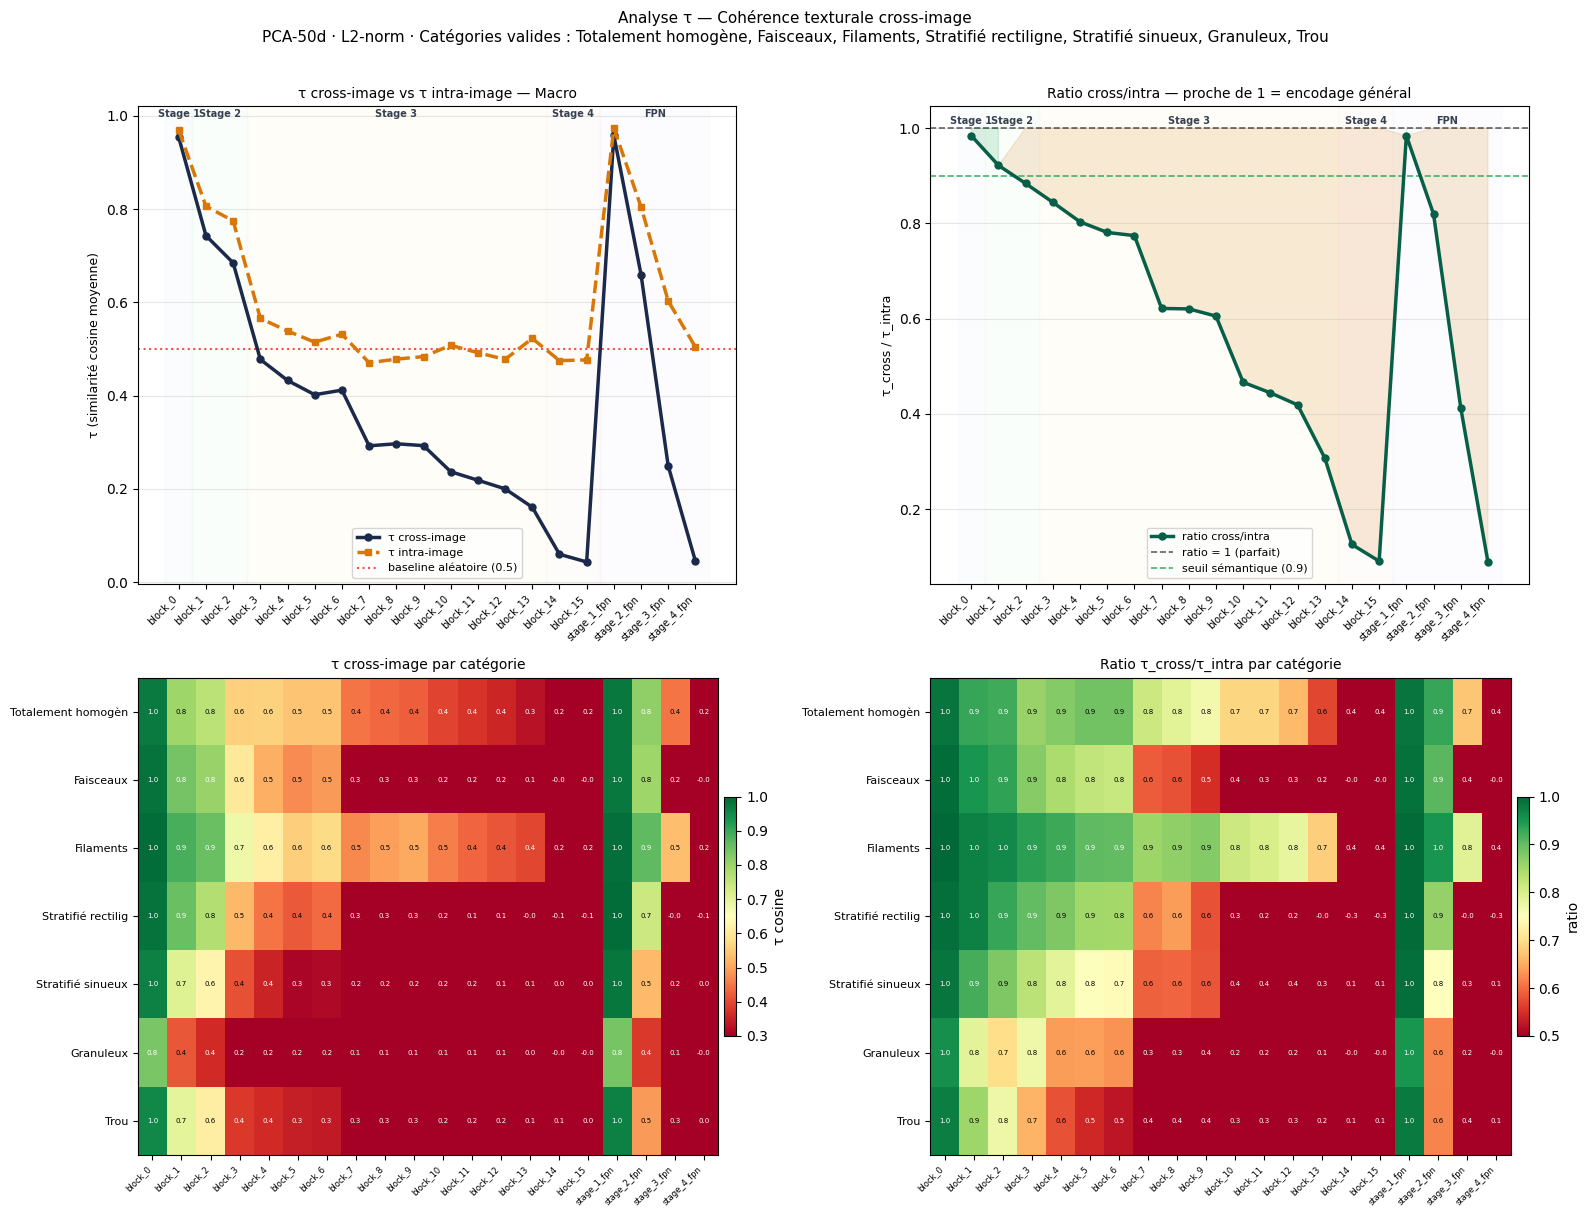

→ Figure sauvegardée : /home/aidouni/meb_texture_seg/outputs/tau/tau_analysis.png
→ Résultats sauvegardés : /home/aidouni/meb_texture_seg/outputs/tau/tau_results.pkl


In [30]:
import pickle as _tau_pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA as _tau_PCA
from tqdm.auto import tqdm

_tau_PCA_DIM      = 50
_tau_SEED         = 42
_tau_MIN_N        = 30
_tau_CATS_EXCLUDE = {2, 8, 10, 11, 12, 13}

_tau_CATS_VALID = sorted([
    int(c) for c in np.unique(CATEGORY_IDS)
    if int(c) not in _tau_CATS_EXCLUDE
    and (CATEGORY_IDS == c).sum() >= _tau_MIN_N
])

_tau_KEYS_ORDER = [
    'block_0',
    'block_1',  'block_2',
    'block_3',  'block_4',  'block_5',  'block_6',  'block_7',
    'block_8',  'block_9',  'block_10', 'block_11', 'block_12', 'block_13',
    'block_14', 'block_15',
    'stage_1_fpn', 'stage_2_fpn', 'stage_3_fpn', 'stage_4_fpn',
]

_tau_STAGE_ZONES = [
    (0,  0,  '#DBEAFE', 'Stage 1'),
    (1,  2,  '#D1FAE5', 'Stage 2'),
    (3,  13, '#FEF3C7', 'Stage 3'),
    (14, 15, '#FEE2E2', 'Stage 4'),
    (16, 19, '#EDE9FE', 'FPN'),
]

print('Catégories utilisées :')
for _tau_c in _tau_CATS_VALID:
    print(f'  Cat {_tau_c:2d}  {CATEGORIES[_tau_c]:<30}  N={(CATEGORY_IDS == _tau_c).sum()}')
print(f'\nPCA : {_tau_PCA_DIM}d  |  blocks : {len(_tau_KEYS_ORDER)}')

# ── Calcul τ cross-image et τ intra-image ────────────────────────────────────
_tau_results = {}

with h5py.File(DB_PATH, 'r') as h5:
    for _tau_key in tqdm(_tau_KEYS_ORDER, desc='Tau'):

        _tau_X_raw  = h5['features'][_tau_key][:]
        _tau_mask_v = np.isin(CATEGORY_IDS, _tau_CATS_VALID)
        _tau_X      = _tau_X_raw[_tau_mask_v]
        _tau_y      = CATEGORY_IDS[_tau_mask_v]
        _tau_imgs   = IMAGE_NAMES[_tau_mask_v]

        # PCA-50d fit sur CATS_VALID uniquement
        _tau_n_comp  = min(_tau_PCA_DIM, _tau_X.shape[1])
        _tau_pca     = _tau_PCA(n_components=_tau_n_comp, random_state=_tau_SEED)
        _tau_X50     = _tau_pca.fit_transform(_tau_X)

        # L2-normalisation → sim cosine = produit scalaire
        _tau_norms  = np.linalg.norm(_tau_X50, axis=1, keepdims=True)
        _tau_X_norm = _tau_X50 / np.where(_tau_norms < 1e-8, 1.0, _tau_norms)

        _tau_cross_per_cat = {}
        _tau_intra_per_cat = {}

        for _tau_c in _tau_CATS_VALID:
            _tau_mask_c = _tau_y == _tau_c
            _tau_Xc     = _tau_X_norm[_tau_mask_c]      # (N_c, 50)
            _tau_imgs_c = _tau_imgs[_tau_mask_c]         # (N_c,)
            _tau_N_c    = _tau_Xc.shape[0]

            # Matrice similarité cosine (N_c × N_c)
            _tau_sim = _tau_Xc @ _tau_Xc.T

            # Masques upper triangulaire (évite doublons et diagonale)
            _tau_upper  = np.triu(np.ones((_tau_N_c, _tau_N_c), dtype=bool), k=1)
            _tau_m_cross = (_tau_imgs_c[:, None] != _tau_imgs_c[None, :]) & _tau_upper
            _tau_m_intra = (_tau_imgs_c[:, None] == _tau_imgs_c[None, :]) & _tau_upper

            _tau_paires_cross = _tau_sim[_tau_m_cross]
            _tau_paires_intra = _tau_sim[_tau_m_intra]

            _tau_cross_per_cat[_tau_c] = (float(_tau_paires_cross.mean())
                                           if _tau_paires_cross.size > 0 else np.nan)
            _tau_intra_per_cat[_tau_c] = (float(_tau_paires_intra.mean())
                                           if _tau_paires_intra.size > 0 else np.nan)

        _tau_cross_vals = [v for v in _tau_cross_per_cat.values() if not np.isnan(v)]
        _tau_intra_vals = [v for v in _tau_intra_per_cat.values() if not np.isnan(v)]

        _tau_cross_macro = float(np.mean(_tau_cross_vals))
        _tau_intra_macro = float(np.mean(_tau_intra_vals))
        _tau_ratio_macro = _tau_cross_macro / (_tau_intra_macro + 1e-8)

        _tau_results[_tau_key] = {
            'cross'       : _tau_cross_per_cat,
            'intra'       : _tau_intra_per_cat,
            'cross_macro' : _tau_cross_macro,
            'intra_macro' : _tau_intra_macro,
            'ratio_macro' : _tau_ratio_macro,
        }

# ── Tableau console ───────────────────────────────────────────────────────────
print(f'\n{"Block":<15} │ {"τ cross":>8} │ {"τ intra":>8} │ '
      f'{"ratio":>6} │ Interprétation')
print('─' * 70)
for _tau_key in _tau_KEYS_ORDER:
    _tau_r     = _tau_results[_tau_key]
    _tau_cross = _tau_r['cross_macro']
    _tau_intra = _tau_r['intra_macro']
    _tau_ratio = _tau_r['ratio_macro']
    if _tau_ratio >= 0.90:
        _tau_interp = 'encodage général ✅'
    elif _tau_ratio >= 0.70:
        _tau_interp = 'partiellement général ⚠️'
    else:
        _tau_interp = 'local uniquement ❌'
    print(f'{_tau_key:<15} │ {_tau_cross:>8.3f} │ {_tau_intra:>8.3f} │ '
          f'{_tau_ratio:>6.3f} │ {_tau_interp}')

_tau_best_cross = max(_tau_results, key=lambda k: _tau_results[k]['cross_macro'])
_tau_best_ratio = max(_tau_results, key=lambda k: _tau_results[k]['ratio_macro'])
print(f'\nBlock optimal τ_cross : {_tau_best_cross} '
      f'→ {_tau_results[_tau_best_cross]["cross_macro"]:.3f}')
print(f'Block optimal ratio   : {_tau_best_ratio} '
      f'→ {_tau_results[_tau_best_ratio]["ratio_macro"]:.3f}')

# ── Figure 2×2 ───────────────────────────────────────────────────────────────
_tau_fig, _tau_axes = plt.subplots(2, 2, figsize=(16, 12))
(_tau_ax00, _tau_ax01), (_tau_ax10, _tau_ax11) = _tau_axes

_tau_x           = np.arange(len(_tau_KEYS_ORDER))
_tau_y_cross     = [_tau_results[k]['cross_macro'] for k in _tau_KEYS_ORDER]
_tau_y_intra     = [_tau_results[k]['intra_macro'] for k in _tau_KEYS_ORDER]
_tau_y_ratio     = [_tau_results[k]['ratio_macro'] for k in _tau_KEYS_ORDER]


def _tau_add_stages(ax, y_max):
    for _xi, _xf, _col, _lbl in _tau_STAGE_ZONES:
        ax.axvspan(_xi - 0.5, _xf + 0.5, alpha=0.12, color=_col)
        ax.text((_xi + _xf) / 2, y_max, _lbl,
                ha='center', va='bottom', fontsize=7,
                color='#374151', fontweight='bold')


# ── ax00 — τ cross et τ intra macro ──────────────────────────────────────────
_tau_add_stages(_tau_ax00, max(max(_tau_y_cross), max(_tau_y_intra)) * 1.02)
_tau_ax00.plot(_tau_x, _tau_y_cross, 'o-', lw=2.5, ms=5,
               color='#1B2A4A', label='τ cross-image', zorder=5)
_tau_ax00.plot(_tau_x, _tau_y_intra, 's--', lw=2.5, ms=5,
               color='#D97706', label='τ intra-image', zorder=5)
_tau_ax00.axhline(0.5, color='red', ls=':', lw=1.5, alpha=0.7,
                  label='baseline aléatoire (0.5)')
_tau_ax00.set_xticks(_tau_x)
_tau_ax00.set_xticklabels(_tau_KEYS_ORDER, rotation=45, ha='right', fontsize=7)
_tau_ax00.set_ylabel('τ (similarité cosine moyenne)', fontsize=9)
_tau_ax00.set_title('τ cross-image vs τ intra-image — Macro', fontsize=10)
_tau_ax00.legend(fontsize=8)
_tau_ax00.grid(True, alpha=0.3, axis='y')

# ── ax01 — Ratio τ_cross / τ_intra ───────────────────────────────────────────
_tau_add_stages(_tau_ax01, max(_tau_y_ratio) * 1.02)
_tau_ax01.plot(_tau_x, _tau_y_ratio, 'o-', lw=2.5, ms=5,
               color='#065F46', zorder=5, label='ratio cross/intra')
_tau_ax01.axhline(1.0, color='black', ls='--', lw=1.2, alpha=0.6,
                  label='ratio = 1 (parfait)')
_tau_ax01.axhline(0.9, color='#16A34A', ls='--', lw=1.2, alpha=0.8,
                  label='seuil sémantique (0.9)')

# fill_between : vert si ratio >= 0.9, orange sinon
_tau_y_arr = np.array(_tau_y_ratio)
_tau_ax01.fill_between(_tau_x, _tau_y_arr, 1.0,
                       where=_tau_y_arr >= 0.9,
                       alpha=0.15, color='#16A34A', interpolate=True)
_tau_ax01.fill_between(_tau_x, _tau_y_arr, 1.0,
                       where=_tau_y_arr < 0.9,
                       alpha=0.15, color='#D97706', interpolate=True)

_tau_ax01.set_xticks(_tau_x)
_tau_ax01.set_xticklabels(_tau_KEYS_ORDER, rotation=45, ha='right', fontsize=7)
_tau_ax01.set_ylabel('τ_cross / τ_intra', fontsize=9)
_tau_ax01.set_title('Ratio cross/intra — proche de 1 = encodage général', fontsize=10)
_tau_ax01.legend(fontsize=8)
_tau_ax01.grid(True, alpha=0.3, axis='y')

# ── ax10 — Heatmap τ_cross par catégorie ─────────────────────────────────────
_tau_mat_cross = np.array([
    [_tau_results[k]['cross'].get(c, np.nan) for k in _tau_KEYS_ORDER]
    for c in _tau_CATS_VALID
])
_tau_im10 = _tau_ax10.imshow(_tau_mat_cross, aspect='auto',
                              cmap='RdYlGn', vmin=0.3, vmax=1.0)
_tau_ax10.set_xticks(range(len(_tau_KEYS_ORDER)))
_tau_ax10.set_xticklabels(_tau_KEYS_ORDER, rotation=45, ha='right', fontsize=6)
_tau_ax10.set_yticks(range(len(_tau_CATS_VALID)))
_tau_ax10.set_yticklabels([CATEGORIES[c][:18] for c in _tau_CATS_VALID], fontsize=8)
_tau_ax10.set_title('τ cross-image par catégorie', fontsize=10)
plt.colorbar(_tau_im10, ax=_tau_ax10, fraction=0.02, pad=0.01, label='τ cosine')
for _ri in range(len(_tau_CATS_VALID)):
    for _ci in range(len(_tau_KEYS_ORDER)):
        _v = _tau_mat_cross[_ri, _ci]
        if not np.isnan(_v):
            _tau_ax10.text(_ci, _ri, f'{_v:.1f}', ha='center', va='center',
                           fontsize=5, color='black' if 0.4 < _v < 0.8 else 'white')

# ── ax11 — Heatmap ratio τ_cross/τ_intra par catégorie ───────────────────────
_tau_mat_ratio = np.array([
    [(_tau_results[k]['cross'].get(c, np.nan) /
      (_tau_results[k]['intra'].get(c, np.nan) + 1e-8))
     for k in _tau_KEYS_ORDER]
    for c in _tau_CATS_VALID
])
_tau_im11 = _tau_ax11.imshow(_tau_mat_ratio, aspect='auto',
                              cmap='RdYlGn', vmin=0.5, vmax=1.0)
_tau_ax11.set_xticks(range(len(_tau_KEYS_ORDER)))
_tau_ax11.set_xticklabels(_tau_KEYS_ORDER, rotation=45, ha='right', fontsize=6)
_tau_ax11.set_yticks(range(len(_tau_CATS_VALID)))
_tau_ax11.set_yticklabels([CATEGORIES[c][:18] for c in _tau_CATS_VALID], fontsize=8)
_tau_ax11.set_title('Ratio τ_cross/τ_intra par catégorie', fontsize=10)
plt.colorbar(_tau_im11, ax=_tau_ax11, fraction=0.02, pad=0.01, label='ratio')
for _ri in range(len(_tau_CATS_VALID)):
    for _ci in range(len(_tau_KEYS_ORDER)):
        _v = _tau_mat_ratio[_ri, _ci]
        if not np.isnan(_v):
            _tau_ax11.text(_ci, _ri, f'{_v:.1f}', ha='center', va='center',
                           fontsize=5, color='black' if 0.55 < _v < 0.9 else 'white')

_tau_fig.suptitle(
    'Analyse τ — Cohérence texturale cross-image\n'
    'PCA-50d · L2-norm · Catégories valides : '
    + ', '.join(CATEGORIES[c] for c in _tau_CATS_VALID),
    fontsize=11, y=1.01,
)

plt.tight_layout()
_tau_out_dir = ROOT / 'outputs' / 'tau'
_tau_out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(_tau_out_dir / 'tau_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ Figure sauvegardée : {_tau_out_dir}/tau_analysis.png')

with open(_tau_out_dir / 'tau_results.pkl', 'wb') as _tau_f:
    _tau_pickle.dump(_tau_results, _tau_f)
print(f'→ Résultats sauvegardés : {_tau_out_dir}/tau_results.pkl')

## Cell 6 — Segmentation texturale supervisée — LDA sur block_0

In [ ]:
# ── Imports & setup LDA ───────────────────────────────────────────────────────
import sys
import cv2
import torch
import pickle as _lda_pickle
import matplotlib.patches as _lda_mpatches
from PIL import Image
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap, BoundaryNorm

_lda_SAM2 = str(ROOT / 'TextureSAM' / 'sam2')
if _lda_SAM2 not in sys.path:
    sys.path.insert(0, _lda_SAM2)

from sam2.modeling.backbones.hieradet import Hiera
from sam2.modeling.backbones.image_encoder import ImageEncoder, FpnNeck
from sam2.modeling.position_encoding import PositionEmbeddingSine

# ── Paramètres ────────────────────────────────────────────────────────────────
_lda_TARGET_IMG = '310120-pat18-WholeMount-24.tif'
_lda_IMG_PATH   = ROOT / 'PatchTagger_Output' / 'full_images' / _lda_TARGET_IMG
_lda_OUT_DIR    = ROOT / 'outputs' / 'lda'
_lda_OUT_DIR.mkdir(parents=True, exist_ok=True)
_lda_N_COMP    = 6
_lda_CKPT_PATH = ROOT / 'checkpoints' / 'sam2.1_hiera_small_1.pt'
_lda_IMG_SIZE  = 1024
_lda_MEAN      = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_lda_STD       = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

_lda_CATS_VALID = sorted([
    int(c) for c in np.unique(CATEGORY_IDS)
    if int(c) not in {2, 8, 10, 11, 12, 13}
    and (CATEGORY_IDS == c).sum() >= 30
])
_lda_mask_valid = np.isin(CATEGORY_IDS, _lda_CATS_VALID)
_lda_y_valid    = CATEGORY_IDS[_lda_mask_valid]
_lda_imgs_valid = IMAGE_NAMES[_lda_mask_valid]

print(f'Catégories valides : {[CATEGORIES[c] for c in _lda_CATS_VALID]}')
print(f'Image cible        : {_lda_TARGET_IMG}')
print(f'N patches valides  : {_lda_mask_valid.sum()}')


# ── ÉTAPE 1 — Charger features block_0 depuis HDF5 ───────────────────────────
with h5py.File(DB_PATH, 'r') as h5:
    _lda_X_raw = h5['features']['block_0'][:][_lda_mask_valid]   # (N, 96)

_lda_mask_target = _lda_imgs_valid == _lda_TARGET_IMG.encode()
_lda_X_fit       = _lda_X_raw[~_lda_mask_target]
_lda_y_fit       = _lda_y_valid[~_lda_mask_target]

print(f'\nPatches pour fit LDA : {len(_lda_X_fit)}')
print(f'  (TARGET_IMG exclue : {_lda_mask_target.sum()} patches)')


# ── ÉTAPE 2 — Fit LDA ─────────────────────────────────────────────────────────
_lda_scaler   = StandardScaler()
_lda_X_scaled = _lda_scaler.fit_transform(_lda_X_fit)

_lda_lda = LinearDiscriminantAnalysis(n_components=_lda_N_COMP)
_lda_lda.fit(_lda_X_scaled, _lda_y_fit)

print('\nVariance expliquée :')
for _lda_i, _lda_v in enumerate(_lda_lda.explained_variance_ratio_):
    _lda_bar = '█' * int(_lda_v * 50)
    print(f'  Axe {_lda_i+1} : {_lda_v*100:5.1f}%  {_lda_bar}')


# ── ÉTAPE 3 — Scatter plot LDA sur les patches ───────────────────────────────
_lda_X_lda = _lda_lda.transform(_lda_scaler.transform(_lda_X_raw))   # (N, 6)

_lda_fig3, _lda_axes3 = plt.subplots(1, 3, figsize=(18, 5))
for _lda_ax, (_lda_i, _lda_j) in zip(_lda_axes3, [(0, 1), (0, 2), (1, 2)]):
    for _lda_c in _lda_CATS_VALID:
        _lda_mc = _lda_y_valid == _lda_c
        _lda_ax.scatter(
            _lda_X_lda[_lda_mc, _lda_i],
            _lda_X_lda[_lda_mc, _lda_j],
            c=cfg['available_categories'][str(_lda_c)]['color'],
            label=CATEGORIES[_lda_c],
            s=8, alpha=0.5,
        )
    _lda_ax.set_xlabel(
        f'LDA {_lda_i+1} ({_lda_lda.explained_variance_ratio_[_lda_i]*100:.1f}%)')
    _lda_ax.set_ylabel(
        f'LDA {_lda_j+1} ({_lda_lda.explained_variance_ratio_[_lda_j]*100:.1f}%)')
    _lda_ax.set_title(f'LDA {_lda_i+1} vs LDA {_lda_j+1}')
    _lda_ax.legend(fontsize=7, markerscale=2)
    _lda_ax.grid(True, alpha=0.3)

plt.suptitle('Scatter LDA — block_0 — tous les patches MEB', fontsize=12)
plt.tight_layout()
plt.savefig(_lda_OUT_DIR / 'lda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ── ÉTAPE 4 — Feature map complète de TARGET_IMG ─────────────────────────────
def _lda_build_encoder():
    trunk = Hiera(
        embed_dim=96, num_heads=1, stages=(1, 2, 11, 2),
        global_att_blocks=(7, 10, 13),
        window_pos_embed_bkg_spatial_size=(7, 7),
    )
    neck = FpnNeck(
        position_encoding=PositionEmbeddingSine(
            num_pos_feats=256, normalize=True, scale=None, temperature=10000,
        ),
        d_model=256,
        backbone_channel_list=[768, 384, 192, 96],
        kernel_size=1, stride=1, padding=0,
        fpn_interp_model='nearest', fuse_type='sum',
        fpn_top_down_levels=[2, 3],
    )
    return ImageEncoder(trunk=trunk, neck=neck, scalp=1)

def _lda_preprocess(img):
    img_r = img.resize((_lda_IMG_SIZE, _lda_IMG_SIZE), Image.BILINEAR)
    x = torch.from_numpy(np.array(img_r)).float() / 255.0
    return (x.permute(2, 0, 1) - _lda_MEAN) / _lda_STD

_lda_device  = 'cuda' if torch.cuda.is_available() else 'cpu'
_lda_encoder = _lda_build_encoder()
_lda_sd      = torch.load(str(_lda_CKPT_PATH), map_location='cpu', weights_only=True)
_lda_sd      = _lda_sd.get('model', _lda_sd)
_lda_prefix  = 'image_encoder.'
if any(k.startswith(_lda_prefix) for k in _lda_sd):
    _lda_sd = {k[len(_lda_prefix):]: v for k, v in _lda_sd.items()
               if k.startswith(_lda_prefix)}
_lda_encoder.load_state_dict(_lda_sd, strict=False)
_lda_encoder = _lda_encoder.to(_lda_device).eval()
print(f'\nModèle chargé — device : {_lda_device}')

_lda_hook_cap = {}
_lda_hook = _lda_encoder.trunk.blocks[0].register_forward_hook(
    lambda m, inp, out: _lda_hook_cap.update({'block_0': out.detach()})
)
_lda_img    = Image.open(_lda_IMG_PATH).convert('RGB')
_lda_orig_H, _lda_orig_W = _lda_img.height, _lda_img.width
_lda_tensor = _lda_preprocess(_lda_img).unsqueeze(0).to(_lda_device)

with torch.no_grad():
    _lda_encoder(_lda_tensor)
_lda_hook.remove()

_lda_feat_map = _lda_hook_cap['block_0'][0].cpu().numpy()   # (H_feat, W_feat, 96)
_lda_flat     = _lda_feat_map.reshape(-1, 96)
_lda_img_gray = np.array(_lda_img.convert('L'))
_lda_H_feat, _lda_W_feat, _ = _lda_feat_map.shape
print(f'Feature map block_0 : {_lda_feat_map.shape}')


# ── ÉTAPE 5 — Appliquer LDA sur toute la feature map ─────────────────────────
_lda_flat_scaled = _lda_scaler.transform(_lda_flat)
_lda_flat_lda    = _lda_lda.transform(_lda_flat_scaled)                  # (H*W, 6)
_lda_lda_maps    = _lda_flat_lda.reshape(_lda_H_feat, _lda_W_feat, _lda_N_COMP)
_lda_pred_map    = _lda_lda.predict(_lda_flat_scaled).reshape(_lda_H_feat, _lda_W_feat)


# ── ÉTAPE 6 — Figure 1 : 6 cartes LDA ────────────────────────────────────────
_lda_fig6, _lda_axes6 = plt.subplots(2, 4, figsize=(20, 9))

_lda_axes6[0, 0].imshow(_lda_img_gray, cmap='gray')
_lda_axes6[0, 0].set_title('Image originale', fontsize=10)
_lda_axes6[0, 0].axis('off')

for _lda_idx, (_lda_row, _lda_col) in enumerate(
        [(0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2)]):
    _lda_ch   = _lda_lda_maps[:, :, _lda_idx]
    _lda_norm = (_lda_ch - _lda_ch.min()) / (_lda_ch.max() - _lda_ch.min() + 1e-8)
    _lda_full = cv2.resize(_lda_norm, (_lda_orig_W, _lda_orig_H),
                           interpolation=cv2.INTER_LINEAR)
    _lda_ax = _lda_axes6[_lda_row, _lda_col]
    _lda_ax.imshow(_lda_img_gray, cmap='gray', alpha=0.55)
    _lda_im = _lda_ax.imshow(_lda_full, cmap='RdYlGn', alpha=0.55, vmin=0, vmax=1)
    plt.colorbar(_lda_im, ax=_lda_ax, fraction=0.03, pad=0.02)
    _lda_v = _lda_lda.explained_variance_ratio_[_lda_idx] * 100
    _lda_ax.set_title(f'LDA axe {_lda_idx+1} ({_lda_v:.1f}%)', fontsize=9)
    _lda_ax.axis('off')

_lda_rgb = _lda_lda_maps[:, :, :3].copy().astype(np.float64)
for _lda_k in range(3):
    _lda_ch = _lda_rgb[:, :, _lda_k]
    _lda_rgb[:, :, _lda_k] = (_lda_ch - _lda_ch.min()) / (_lda_ch.max() - _lda_ch.min() + 1e-8)
_lda_rgb_full = cv2.resize(_lda_rgb.astype(np.float32), (_lda_orig_W, _lda_orig_H))
_lda_axes6[1, 3].imshow(_lda_img_gray, cmap='gray', alpha=0.4)
_lda_axes6[1, 3].imshow(_lda_rgb_full, alpha=0.65)
_lda_axes6[1, 3].set_title('LDA RGB (axes 1-2-3)', fontsize=9)
_lda_axes6[1, 3].axis('off')

plt.suptitle(
    f'Cartes LDA — block_0 — {_lda_TARGET_IMG}\n'
    'Vert=élevé · Rouge=faible · Frontière=changement de couleur',
    fontsize=11,
)
plt.tight_layout()
plt.savefig(_lda_OUT_DIR / 'lda_maps.png', dpi=150, bbox_inches='tight')
plt.show()


# ── ÉTAPE 7 — Figure 2 : prédiction par pixel ────────────────────────────────
_lda_pred_full = cv2.resize(
    _lda_pred_map.astype(np.float32),
    (_lda_orig_W, _lda_orig_H),
    interpolation=cv2.INTER_NEAREST,
)

_lda_cmap_cat = ListedColormap([
    cfg['available_categories'][str(c)]['color'] for c in sorted(_lda_CATS_VALID)
])
_lda_bounds   = [c - 0.5 for c in sorted(_lda_CATS_VALID)] + [max(_lda_CATS_VALID) + 0.5]
_lda_norm_cat = BoundaryNorm(_lda_bounds, _lda_cmap_cat.N)

_lda_fig7, (_lda_ax1, _lda_ax2) = plt.subplots(1, 2, figsize=(14, 5))
_lda_ax1.imshow(_lda_img_gray, cmap='gray')
_lda_ax1.set_title('Image originale', fontsize=11)
_lda_ax1.axis('off')

_lda_ax2.imshow(_lda_img_gray, cmap='gray', alpha=0.4)
_lda_ax2.imshow(_lda_pred_full, cmap=_lda_cmap_cat, norm=_lda_norm_cat, alpha=0.6)
_lda_ax2.legend(
    handles=[
        _lda_mpatches.Patch(
            color=cfg['available_categories'][str(c)]['color'],
            label=CATEGORIES[c],
        )
        for c in sorted(_lda_CATS_VALID)
    ],
    loc='upper right', fontsize=8, framealpha=0.85,
)
_lda_ax2.set_title(
    f'Prédiction LDA par pixel — block_0\n'
    f'LDA appris sur {len(_lda_X_fit)} patches (TARGET_IMG exclue)',
    fontsize=10,
)
_lda_ax2.axis('off')
plt.suptitle(f'Segmentation texturale supervisée — {_lda_TARGET_IMG}', fontsize=12)
plt.tight_layout()
plt.savefig(_lda_OUT_DIR / 'lda_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Sauvegarde ────────────────────────────────────────────────────────────────
with open(_lda_OUT_DIR / 'lda_model.pkl', 'wb') as _lda_f:
    _lda_pickle.dump({
        'lda'       : _lda_lda,
        'scaler'    : _lda_scaler,
        'cats_valid': _lda_CATS_VALID,
        'target_img': _lda_TARGET_IMG,
    }, _lda_f)
print(f'\n→ {_lda_OUT_DIR}/lda_scatter.png')
print(f'→ {_lda_OUT_DIR}/lda_maps.png')
print(f'→ {_lda_OUT_DIR}/lda_prediction.png')
print(f'→ {_lda_OUT_DIR}/lda_model.pkl')

## Cell 7 — Pairwise Fisher : séparabilité par paire de catégories

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as _pf_PCA

_pf_KEY     = 'block_0'
_pf_PCA_DIM = 50
_pf_SEED    = 42
_pf_MIN_N   = 30
_pf_EXCLUDE = {2, 8, 10, 11, 12, 13}

_pf_CATS_VALID = sorted([
    int(c) for c in np.unique(CATEGORY_IDS)
    if int(c) not in _pf_EXCLUDE
    and (CATEGORY_IDS == c).sum() >= _pf_MIN_N
])
_pf_mask_valid = np.isin(CATEGORY_IDS, _pf_CATS_VALID)
_pf_y_valid    = CATEGORY_IDS[_pf_mask_valid]

print(f'Catégories ({len(_pf_CATS_VALID)}) :')
for _pf_c in _pf_CATS_VALID:
    print(f'  Cat {_pf_c:2d}  {CATEGORIES[_pf_c]:<30}  N={(CATEGORY_IDS == _pf_c).sum()}')

# ── Chargement + PCA-50d ──────────────────────────────────────────────────────
with h5py.File(DB_PATH, 'r') as h5:
    _pf_X_raw = h5['features'][_pf_KEY][:][_pf_mask_valid]

_pf_pca  = _pf_PCA(n_components=_pf_PCA_DIM, random_state=_pf_SEED)
_pf_X_50 = _pf_pca.fit_transform(_pf_X_raw)
print(f'\nPCA {_pf_PCA_DIM}d : {_pf_pca.explained_variance_ratio_.sum()*100:.1f}% variance')

# ── Centroïdes + variances par catégorie ──────────────────────────────────────
_pf_centroids = {}
_pf_variances = {}

for _pf_c in _pf_CATS_VALID:
    _pf_Xc              = _pf_X_50[_pf_y_valid == _pf_c]
    _pf_centroids[_pf_c] = _pf_Xc.mean(axis=0)
    _pf_variances[_pf_c] = float(np.mean(np.var(_pf_Xc, axis=0)))

print('\nVariances intra-classe :')
for _pf_c in _pf_CATS_VALID:
    print(f'  {CATEGORIES[_pf_c]:<28} σ²={_pf_variances[_pf_c]:.4f}')

# ── Matrice Pairwise Fisher ───────────────────────────────────────────────────
_pf_n        = len(_pf_CATS_VALID)
_pf_J_matrix = np.full((_pf_n, _pf_n), np.nan)

for _pf_a, _pf_ci in enumerate(_pf_CATS_VALID):
    for _pf_b, _pf_cj in enumerate(_pf_CATS_VALID):
        if _pf_a == _pf_b:
            continue
        _pf_diff           = _pf_centroids[_pf_ci] - _pf_centroids[_pf_cj]
        _pf_num            = float(_pf_diff @ _pf_diff)
        _pf_den            = _pf_variances[_pf_ci] + _pf_variances[_pf_cj]
        _pf_J_matrix[_pf_a, _pf_b] = _pf_num / (_pf_den + 1e-10)

# ── Print paires triées ───────────────────────────────────────────────────────
_pf_paires = []
for _pf_a in range(_pf_n):
    for _pf_b in range(_pf_a + 1, _pf_n):
        _pf_paires.append((
            _pf_J_matrix[_pf_a, _pf_b],
            CATEGORIES[_pf_CATS_VALID[_pf_a]],
            CATEGORIES[_pf_CATS_VALID[_pf_b]],
        ))
_pf_paires.sort()

print('\n=== Paires de textures triées par séparabilité ===')
print('\n--- Paires les PLUS DIFFICILES à séparer (J faible) ---')
for _pf_J, _pf_c1, _pf_c2 in _pf_paires[:5]:
    print(f'  {_pf_c1:<22} ↔ {_pf_c2:<22} : J={_pf_J:.2f}')

print('\n--- Paires les PLUS FACILES à séparer (J élevé) ---')
for _pf_J, _pf_c1, _pf_c2 in _pf_paires[-5:]:
    print(f'  {_pf_c1:<22} ↔ {_pf_c2:<22} : J={_pf_J:.2f}')

# ── Figure — heatmap 7×7 ─────────────────────────────────────────────────────
_pf_fig, _pf_ax = plt.subplots(figsize=(9, 8))

_pf_masked = np.ma.masked_invalid(_pf_J_matrix)
_pf_vmin   = float(np.nanmin(_pf_J_matrix[~np.isnan(_pf_J_matrix)]))
_pf_vmax   = float(np.nanmax(_pf_J_matrix[~np.isnan(_pf_J_matrix)]))

_pf_im = _pf_ax.imshow(
    _pf_masked, cmap='RdYlGn',
    norm=matplotlib.colors.LogNorm(vmin=_pf_vmin, vmax=_pf_vmax),
)

_pf_labels = [CATEGORIES[c] for c in _pf_CATS_VALID]
_pf_ax.set_xticks(range(_pf_n))
_pf_ax.set_yticks(range(_pf_n))
_pf_ax.set_xticklabels(_pf_labels, rotation=45, ha='right', fontsize=9)
_pf_ax.set_yticklabels(_pf_labels, fontsize=9)

for _pf_a in range(_pf_n):
    for _pf_b in range(_pf_n):
        if _pf_a != _pf_b:
            _pf_val   = _pf_J_matrix[_pf_a, _pf_b]
            _pf_color = 'white' if _pf_val < 5 else '#1a1a2e'
            _pf_ax.text(_pf_b, _pf_a, f'{_pf_val:.1f}',
                        ha='center', va='center',
                        color=_pf_color, fontsize=8)
        else:
            _pf_ax.text(_pf_b, _pf_a, '—',
                        ha='center', va='center',
                        color='gray', fontsize=10)

plt.colorbar(_pf_im, ax=_pf_ax, fraction=0.046, pad=0.04,
             label='Fisher J (log) · vert=séparable, rouge=confus')
_pf_ax.set_title(
    f'Pairwise Fisher — {_pf_KEY}\n'
    'J élevé = paire facile à séparer · J faible = textures confondues',
    fontsize=12,
)
plt.tight_layout()
_pf_out_dir = ROOT / 'outputs' / 'fisher'
_pf_out_dir.mkdir(parents=True, exist_ok=True)
_pf_fig_path = _pf_out_dir / f'pairwise_fisher_{_pf_KEY}.png'
plt.savefig(_pf_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'→ Figure sauvegardée : {_pf_fig_path}')

## Cell 8 — CAH Ward : structure hiérarchique des textures

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as _dend_PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

_dend_KEY     = 'block_0'
_dend_PCA_DIM = 50
_dend_SEED    = 42
_dend_EXCLUDE = {2, 8, 10, 11, 12, 13}
_dend_MIN_N   = 30

_dend_CATS_VALID = sorted([
    int(c) for c in np.unique(CATEGORY_IDS)
    if int(c) not in _dend_EXCLUDE
    and (CATEGORY_IDS == c).sum() >= _dend_MIN_N
])
_dend_mask_valid = np.isin(CATEGORY_IDS, _dend_CATS_VALID)
_dend_y_valid    = CATEGORY_IDS[_dend_mask_valid]

# ── PCA-50d + L2-norm ─────────────────────────────────────────────────────────
with h5py.File(DB_PATH, 'r') as h5:
    _dend_X_raw = h5['features'][_dend_KEY][:][_dend_mask_valid]

_dend_pca   = _dend_PCA(n_components=_dend_PCA_DIM, random_state=_dend_SEED)
_dend_X_50  = _dend_pca.fit_transform(_dend_X_raw)
_dend_norms = np.linalg.norm(_dend_X_50, axis=1, keepdims=True)
_dend_X_norm = _dend_X_50 / np.where(_dend_norms < 1e-8, 1.0, _dend_norms)

print(f'PCA {_dend_PCA_DIM}d : {_dend_pca.explained_variance_ratio_.sum()*100:.1f}% variance')

# ── Centroïdes L2-normalisés par catégorie ────────────────────────────────────
_dend_centroids = []
_dend_cat_order = []
for _dend_c in _dend_CATS_VALID:
    _dend_mu = _dend_X_norm[_dend_y_valid == _dend_c].mean(axis=0)
    _dend_mu = _dend_mu / (np.linalg.norm(_dend_mu) + 1e-10)
    _dend_centroids.append(_dend_mu)
    _dend_cat_order.append(_dend_c)
_dend_centroids = np.array(_dend_centroids)   # (7, 50)

# ── Distance cosine + CAH Ward ────────────────────────────────────────────────
_dend_dist_condensed = pdist(_dend_centroids, metric='cosine')
_dend_dist_matrix    = squareform(_dend_dist_condensed)
_dend_Z              = linkage(_dend_centroids, method='ward')

print('Centroïdes calculés :')
for _dend_i, _dend_c in enumerate(_dend_cat_order):
    print(f'  {CATEGORIES[_dend_c]:<28}  norm={np.linalg.norm(_dend_centroids[_dend_i]):.4f}')

# ── Figure 1×2 ────────────────────────────────────────────────────────────────
_dend_fig, (_dend_ax1, _dend_ax2) = plt.subplots(
    1, 2, figsize=(16, 6),
    gridspec_kw={'width_ratios': [1.2, 1]},
)

_dend_labels_cat = [CATEGORIES[c] for c in _dend_cat_order]

dendrogram(
    _dend_Z,
    labels=_dend_labels_cat,
    ax=_dend_ax1,
    color_threshold=0.7 * max(_dend_Z[:, 2]),
    leaf_font_size=10,
)
_dend_ax1.set_title(
    f'Dendrogramme des textures — {_dend_KEY}\nCAH Ward sur centroïdes',
    fontsize=12,
)
_dend_ax1.set_ylabel('Distance de fusion', fontsize=11)
_dend_ax1.set_xticklabels(
    _dend_ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9,
)
for _dend_lbl in _dend_ax1.get_xticklabels():
    for _dend_c in _dend_cat_order:
        if CATEGORIES[_dend_c] == _dend_lbl.get_text():
            _dend_lbl.set_color(cfg['available_categories'][str(_dend_c)]['color'])

_dend_im = _dend_ax2.imshow(_dend_dist_matrix, cmap='RdYlGn_r', vmin=0)
_dend_ax2.set_xticks(range(len(_dend_cat_order)))
_dend_ax2.set_yticks(range(len(_dend_cat_order)))
_dend_ax2.set_xticklabels(_dend_labels_cat, rotation=45, ha='right', fontsize=8)
_dend_ax2.set_yticklabels(_dend_labels_cat, fontsize=8)
for _dend_i in range(len(_dend_cat_order)):
    for _dend_j in range(len(_dend_cat_order)):
        _dend_val = _dend_dist_matrix[_dend_i, _dend_j]
        _dend_ax2.text(
            _dend_j, _dend_i, f'{_dend_val:.2f}',
            ha='center', va='center', fontsize=7,
            color='white' if _dend_val > _dend_dist_matrix.max() * 0.6
                          else '#1a1a2e',
        )
plt.colorbar(_dend_im, ax=_dend_ax2, fraction=0.046, pad=0.04,
             label='Distance cosine entre centroïdes')
_dend_ax2.set_title('Distance entre centroïdes de textures', fontsize=12)

plt.suptitle(
    f'Structure hiérarchique des textures — {_dend_KEY}',
    fontsize=13,
)
plt.tight_layout()
_dend_out_dir = ROOT / 'outputs' / 'fisher'
_dend_out_dir.mkdir(parents=True, exist_ok=True)
_dend_fig_path = _dend_out_dir / f'dendrogram_textures_{_dend_KEY}.png'
plt.savefig(_dend_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'→ Figure sauvegardée : {_dend_fig_path}')

# ── Fusions hiérarchiques ─────────────────────────────────────────────────────
print('\n=== Ordre des fusions (CAH Ward) ===\n')
_dend_n_leaves     = len(_dend_cat_order)
_dend_cluster_names = {i: CATEGORIES[_dend_cat_order[i]]
                       for i in range(_dend_n_leaves)}
for _dend_idx, (_dend_a, _dend_b, _dend_dist, _dend_size) in enumerate(_dend_Z):
    _dend_a, _dend_b = int(_dend_a), int(_dend_b)
    _dend_name_a     = _dend_cluster_names[_dend_a]
    _dend_name_b     = _dend_cluster_names[_dend_b]
    _dend_cluster_names[_dend_n_leaves + _dend_idx] = f'({_dend_name_a} + {_dend_name_b})'
    print(f'Fusion {_dend_idx+1} (dist={_dend_dist:.3f}) :  '
          f'{_dend_name_a}  +  {_dend_name_b}')

# ── Groupes à K=2, 3, 4 ──────────────────────────────────────────────────────
print('\n=== Implication pour la segmentation ===\n')
for _dend_k in [2, 3, 4]:
    _dend_clusters = fcluster(_dend_Z, t=_dend_k, criterion='maxclust')
    print(f'Si CAH coupe à K={_dend_k} :')
    _dend_groupes = {}
    for _dend_i, _dend_cl in enumerate(_dend_clusters):
        _dend_groupes.setdefault(_dend_cl, []).append(CATEGORIES[_dend_cat_order[_dend_i]])
    for _dend_cl, _dend_membres in sorted(_dend_groupes.items()):
        print(f'  Groupe {_dend_cl} : {", ".join(_dend_membres)}')
    print()